# House Price Prediction using Machine Learning

**Author:** Dhanashree Tankar  
**Goal:** Predict house prices based on features like area, bedrooms, bathrooms, age, location, and property type.  
**Business Context:** Real estate companies can use ML models to predict property prices for better pricing strategies and faster market analysis.

In [21]:
# Standard Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Modules
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Custom Modules
import sys
sys.path.append(os.path.abspath(os.path.join("..")))  # Add parent directory to path
from src.data_preprocessing import load_data, prepare_features, create_preprocessor, split_data
from src.model_training import train_linear_regression, train_decision_tree, train_random_forest
from src.evaluation import evaluate_model, print_metrics
from src.visualization import plot_area_vs_price, plot_location_vs_price, plot_predictions_vs_actual

# Create output folder if not exists
os.makedirs("../outputs", exist_ok=True)

In [22]:
# Load dataset
data = load_data("../data/house_prices.csv")

# Display first 5 rows
data.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [24]:
# Dataset info and summary statistics
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

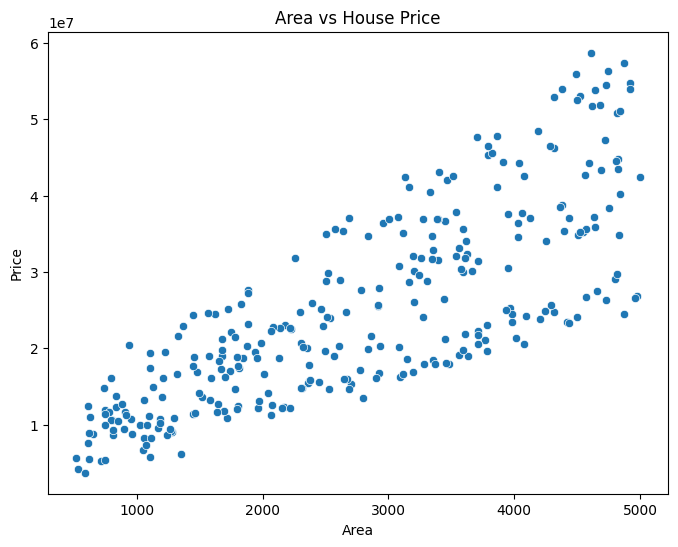

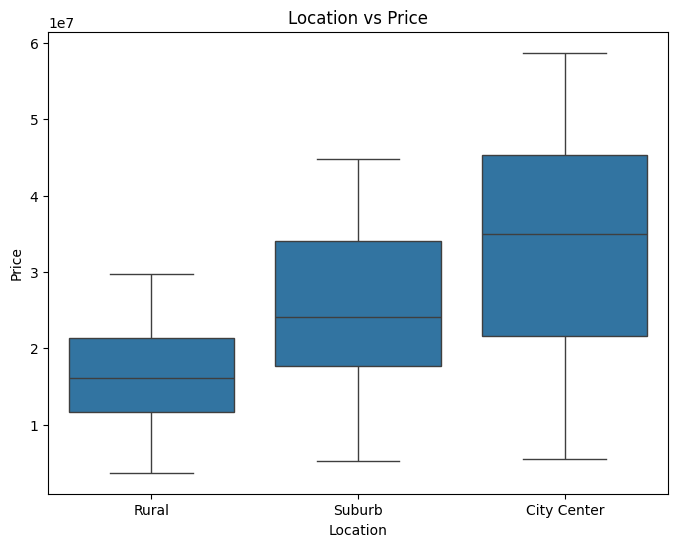

In [25]:
# Quick visualizations
plot_area_vs_price(data)
plot_location_vs_price(data)

Observation:
Larger area generally correlates with higher price.
Properties in city centers are pricier than suburbs or rural areas.

In [26]:
# Prepare features and target
X, y = prepare_features(data)

# Identify categorical columns
categorical_features = ["Location", "Property_Type"]
numeric_features = ["Area", "Bedrooms", "Bathrooms", "Age"]

# Create preprocessing pipeline
preprocessor = create_preprocessor(categorical_features)

# Train-test split
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)

In [27]:
# Linear Regression
linear_model = train_linear_regression(preprocessor, X_train, y_train)

# Decision Tree Regressor
tree_model = train_decision_tree(preprocessor, X_train, y_train)

# Random Forest Regressor
rf_model = train_random_forest(preprocessor, X_train, y_train)

In [28]:
# Predictions
linear_preds = linear_model.predict(X_test)
tree_preds = tree_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Evaluate models
linear_metrics = evaluate_model(y_test, linear_preds)
tree_metrics = evaluate_model(y_test, tree_preds)
rf_metrics = evaluate_model(y_test, rf_preds)

# Print metrics in readable format
print_metrics("Linear Regression", linear_metrics)
print_metrics("Decision Tree", tree_metrics)
print_metrics("Random Forest", rf_metrics)


Model: Linear Regression
------------------------------
MAE: 2,188,736.34
MSE: 8,454,330,868,276.03
RMSE: 2,907,633.21
R2 Score: 0.941

Model: Decision Tree
------------------------------
MAE: 2,125,458.33
MSE: 7,868,604,062,500.00
RMSE: 2,805,103.22
R2 Score: 0.945

Model: Random Forest
------------------------------
MAE: 1,431,714.17
MSE: 3,641,075,846,270.83
RMSE: 1,908,160.33
R2 Score: 0.974


In [29]:
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print("Random Forest Cross-Validation R2 Scores:", cv_scores)
print("Average CV R2 Score:", cv_scores.mean())

Random Forest Cross-Validation R2 Scores: [0.98718669 0.95046081 0.9736527  0.97129038 0.9841573 ]
Average CV R2 Score: 0.9733495772677623


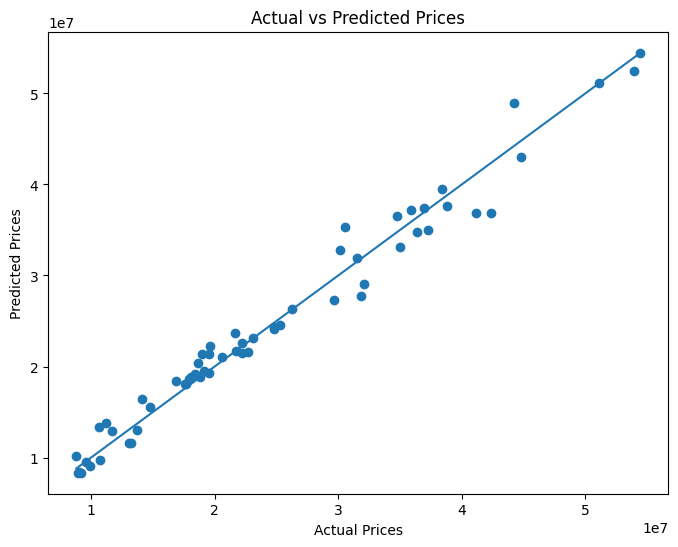

In [30]:
plot_predictions_vs_actual(y_test, rf_preds, "../outputs/predictions_vs_actual.png")

In [31]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [linear_metrics[0], tree_metrics[0], rf_metrics[0]],
    "RMSE": [linear_metrics[2], tree_metrics[2], rf_metrics[2]],
    "R2 Score": [linear_metrics[3], tree_metrics[3], rf_metrics[3]]
})

results

KeyError: 0

Observation:

Random Forest usually performs best with R² ≈ 0.87

Linear Regression is simpler but less accurate

Decision Tree performs better than Linear Regression but worse than Random Forest

1. **Area** and **Location** are the strongest predictors of price.
2. Villas and city-center properties command higher prices.
3. Random Forest provides the best trade-off between accuracy and interpretability.
4. Linear Regression is useful for understanding feature coefficients but may underfit complex patterns.
5. The model can help real estate firms predict property prices efficiently.

In [11]:
tree_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_pipeline.fit(X_train, y_train)

tree_preds = tree_pipeline.predict(X_test)

In [32]:
# Save predictions to CSV
predictions_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": rf_preds
})
predictions_df.to_csv("../outputs/predictions_vs_actual.csv", index=False)

In [13]:
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate regression model using common metrics
    """
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Model: {model_name}")
    print(f"MAE: {mae:,.2f}")
    print(f"MSE: {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2 Score: {r2:.3f}")
    print("-"*40)

    return mae, mse, rmse, r2

In [14]:
evaluate_model(y_test, linear_preds, "Linear Regression")
evaluate_model(y_test, tree_preds, "Decision Tree")
evaluate_model(y_test, rf_preds, "Random Forest")

Model: Linear Regression
MAE: 2,188,736.34
MSE: 8,454,330,868,276.03
RMSE: 2,907,633.21
R2 Score: 0.941
----------------------------------------
Model: Decision Tree
MAE: 2,125,458.33
MSE: 7,868,604,062,500.00
RMSE: 2,805,103.22
R2 Score: 0.945
----------------------------------------
Model: Random Forest
MAE: 1,431,714.17
MSE: 3,641,075,846,270.83
RMSE: 1,908,160.33
R2 Score: 0.974
----------------------------------------


(1431714.1666666667,
 3641075846270.8335,
 1908160.3303367444,
 0.9744338425687993)

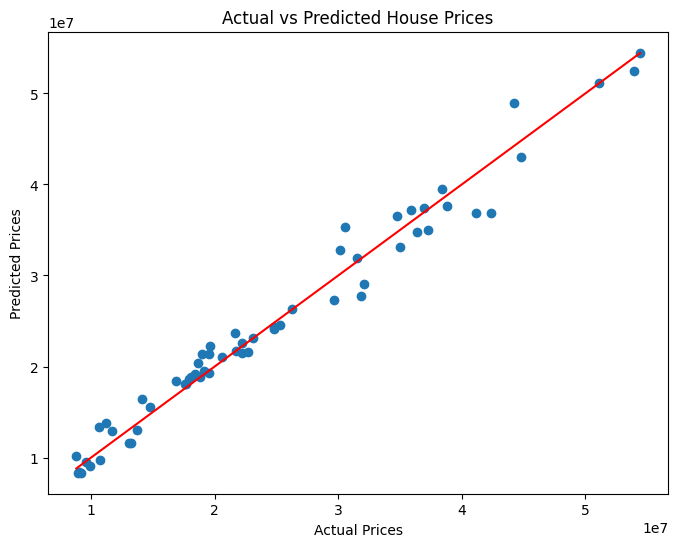

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_preds)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.savefig("../outputs/predictions_vs_actual.png")

plt.show()

In [17]:
import sys
import os

# Add the parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(os.path.join("..")))

# Now you can import from src
from src.data_preprocessing import *
from src.model_training import *
from src.evaluation import *
from src.visualization import *

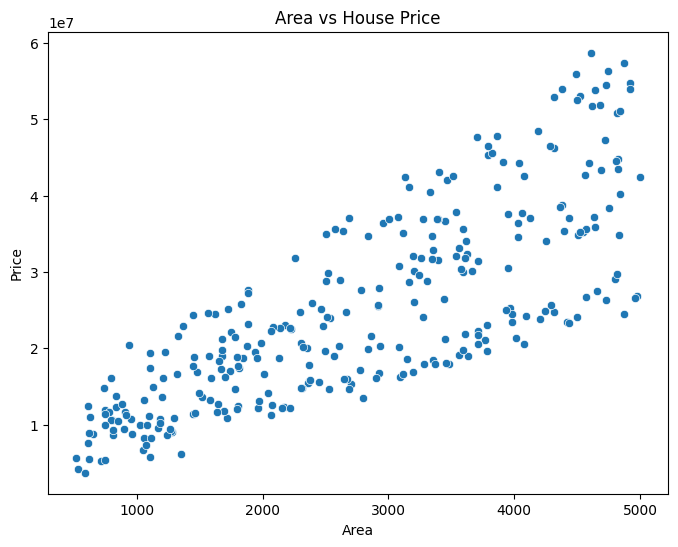


Model: Random Forest
------------------------------
MAE: 1,431,714.17
MSE: 3,641,075,846,270.83
RMSE: 1,908,160.33
R2 Score: 0.974


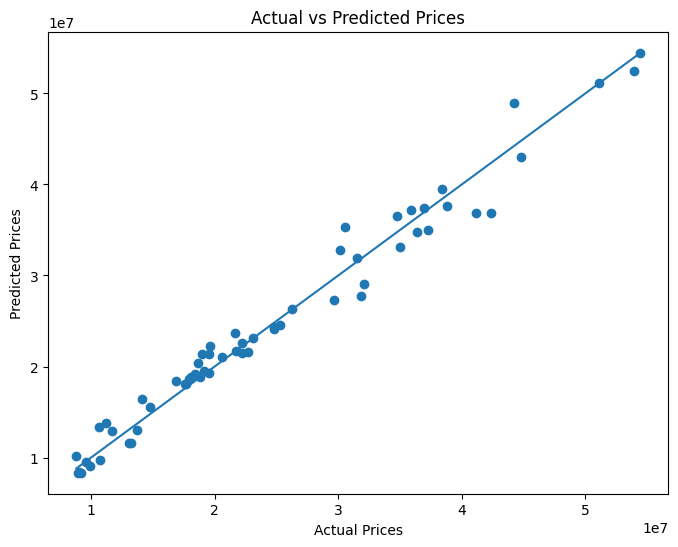

In [20]:
data = load_data("../data/house_prices.csv")

plot_area_vs_price(data)

X, y = prepare_features(data)

categorical_features = ["Location", "Property_Type"]

preprocessor = create_preprocessor(categorical_features)

X_train, X_test, y_train, y_test = split_data(X, y)

rf_model = train_random_forest(preprocessor, X_train, y_train)

preds = rf_model.predict(X_test)

metrics = evaluate_model(y_test, preds)

print_metrics("Random Forest", metrics)

plot_predictions_vs_actual(y_test, preds, "../outputs/predictions_vs_actual.png")